# Here lies a Business-Oriented Data Analysis of an IMDB Dataset

### 1. We Import all Dependencies Needed

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime
import seaborn as sns

### 2. We Extract the Data from an Excel File

In [2]:
URL_PATH = os.getcwd() + "\\Datasets_option1\\imdb.xlsx"

imdb_df = pd.read_excel(URL_PATH)

imdb_df.head(1)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469


### 3. Let's Analyze the Dataset

In [3]:
imdb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 831 entries, 0 to 830
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    831 non-null    str    
 1   Series_Title   831 non-null    str    
 2   Released_Year  831 non-null    str    
 3   Certificate    785 non-null    str    
 4   Runtime        831 non-null    int64  
 5   Genre          831 non-null    str    
 6   IMDB_Rating    831 non-null    float64
 7   Overview       831 non-null    str    
 8   Meta_score     750 non-null    float64
 9   Director       831 non-null    str    
 10  Star1          831 non-null    str    
 11  Star2          831 non-null    str    
 12  Star3          831 non-null    str    
 13  Star4          831 non-null    str    
 14  No_of_Votes    831 non-null    int64  
 15  Gross          831 non-null    int64  
dtypes: float64(2), int64(3), str(11)
memory usage: 104.0 KB


In terms of data types, everything seems ok, unless maybe the Released_year format. We'll clean that later

In [4]:
imdb_df.describe()

,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,831.000000,831.000000,750.000000,8.310000e+02,8.310000e+02
mean,124.078219,7.946931,77.460000,3.152499e+05,6.803475e+07
std,27.501455,0.283204,12.493967,3.436443e+05,1.097500e+08
min,45.000000,7.600000,28.000000,2.508800e+04,1.305000e+03
25%,104.000000,7.700000,70.000000,7.143000e+04,3.253559e+06
50%,120.000000,7.900000,78.000000,1.867340e+05,2.353089e+07
75%,138.000000,8.100000,86.000000,4.457210e+05,8.075089e+07
max,242.000000,9.300000,100.000000,2.343110e+06,9.366622e+08


No issues so far, unless maybe the count of Meta_score. We'll have to check whether this is blank or NaN values

In [5]:
imdb_df['Meta_score'].isna().sum()

np.int64(81)

It confirms us that these are NaN values, what will not hinder our analysis because Meta_score are float values.

In [6]:
imdb_df['Certificate'].isna().sum()

np.int64(46)

In that case, we'll have to convert these NaN values as Certificate column is of String format

In [7]:
imdb_df["Released_Year"].unique()

<StringArray>
['1994', '1972', '2008', '1974', '1957', '2003', '1993', '2010', '1999',
 '2001', '1966', '2002', '1990', '1980', '1975', '2019', '2014', '1998',
 '1997', '1995', '1991', '1977', '1954', '2011', '2006', '2000', '1988',
 '1985', '1968', '1960', '1942', '1936', '1931', '2018', '2016', '2017',
 '2012', '2009', '2007', '1984', '1981', '1979', '1964', '1940', '2004',
 '1992', '1987', '1986', '1983', '1976', '1973', '1971', '1965', '1962',
 '1959', '1958', '1952', '1948', '1944', '1941', '1927', '1921', '2015',
 '2013', '2005', '1989', '1963', '1955', '1950', '1925', '1924', '1996',
 '1982', '1978', '1967', '1951', '1949', '1939', '1937', '1934', '1928',
 '1926', '1970', '1969', '1961', '1946', '1930', '1956', '1947', '1945',
 '1938', '1935', '1933',   'PG', '1953']
Length: 95, dtype: str

In [8]:
pos = imdb_df["Released_Year"].loc[imdb_df["Released_Year"] == 'PG'].index[0]
imdb_df["Certificate"].iloc[pos]

'U'

In [9]:
imdb_df["Certificate"].value_counts()

Certificate
U           200
A           180
UA          163
R           135
PG-13        39
PG           24
Passed       23
G            10
Approved      6
GP            2
Unrated       1
TV-PG         1
U/A           1
Name: count, dtype: int64

As we can see there's an anomally here, the "PG" should not be inside the Released_Year column. We'll clean that too

In [10]:
imdb_df["Genre"].value_counts()

Genre
Drama                        75
Drama, Romance               31
Comedy, Drama                29
Comedy, Drama, Romance       26
Crime, Drama, Thriller       25
                             ..
Action, Adventure, Family     1
Action, Crime, Mystery        1
Animation, Drama, Romance     1
Drama, War, Western           1
Adventure, Comedy, War        1
Name: count, Length: 182, dtype: int64

The column Genre seems scattered too, we'll clean it by aggregating values.

### 4. Now It's Time for Cleaning the Data

First let's convert the Released_year column into a datetime object

In [11]:
imdb_df["Released_Year"] = pd.to_datetime(imdb_df["Released_Year"], format="%Y", errors="coerce")
imdb_df["Released_Year"].info()

<class 'pandas.Series'>
RangeIndex: 831 entries, 0 to 830
Series name: Released_Year
Non-Null Count  Dtype         
--------------  -----         
830 non-null    datetime64[us]
dtypes: datetime64[us](1)
memory usage: 6.6 KB


Second, let's optimize the Certificate column

In [12]:
mapping = {
    "U/A": "UA",
    "TV-PG": "PG",
    "Passed": "U",
    "Approved": "U",
    "GP": "PG"
}

imdb_df["Certificate"] = imdb_df["Certificate"].replace(mapping)

In [13]:
imdb_df["Certificate"].value_counts()

Certificate
U          229
A          180
UA         164
R          135
PG-13       39
PG          27
G           10
Unrated      1
Name: count, dtype: int64

Third, let's put all column names into lower case for more efficiency

In [14]:
imdb_df.columns = imdb_df.columns.str.lower()
imdb_df.columns

Index(['poster_link', 'series_title', 'released_year', 'certificate',
       'runtime', 'genre', 'imdb_rating', 'overview', 'meta_score', 'director',
       'star1', 'star2', 'star3', 'star4', 'no_of_votes', 'gross'],
      dtype='str')

Four, we transform genre column in a more usable way using "get_dummies"

In [15]:
genres = imdb_df["genre"].str.get_dummies(sep=", ")
imdb_df = pd.concat([imdb_df, genres], axis=1)
genres.head(1)

,Action,Adventure,Animation,Biography,Comedy,Crime,Drama,Family,Fantasy,Film-Noir,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Finally, let's keep only the relevant columns

In [16]:
imdb_df = imdb_df.drop(columns=["poster_link", "overview", "genre"])
imdb_df.head(1)

,series_title,released_year,certificate,runtime,imdb_rating,meta_score,director,star1,star2,star3,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,The Shawshank Redemption,1994-01-01,A,142,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,...,0,0,0,0,0,0,0,0,0,0


### 5. The Dataset is Ready. It's time to Analyze and Dress Meaningful Observation

In [17]:
imdb_df.head(1)

,series_title,released_year,certificate,runtime,imdb_rating,meta_score,director,star1,star2,star3,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,The Shawshank Redemption,1994-01-01,A,142,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,...,0,0,0,0,0,0,0,0,0,0


#### A Small Summary

In [18]:
nb_movies = len(imdb_df)
oldest_year = imdb_df["released_year"].sort_values().iloc[0].year
newest_year = imdb_df["released_year"].sort_values().iloc[-2].year
highest_im_rating = np.max(imdb_df["imdb_rating"])
lowest_im_rating = np.min(imdb_df["imdb_rating"])
highest_meta_score = np.max(imdb_df["meta_score"])
lowest_meta_score = np.min(imdb_df["meta_score"])
nb_genres = len(genres.columns)

In [19]:
print(f"This IMDB Dataset shows information about the {nb_movies} highest rated movies classed into {nb_genres} different genres.\n\
The oldest movie from that list was released in {oldest_year}, while the newest in {newest_year}.\n\
IMDB Rating (audience) goes from {lowest_im_rating} to {highest_im_rating}.\n\
Meta Score (critics) goes from {lowest_meta_score} to {highest_meta_score}")

This IMDB Dataset shows information about the 831 highest rated movies classed into 21 different genres.
The oldest movie from that list was released in 1921, while the newest in 2019.
IMDB Rating (audience) goes from 7.6 to 9.3.
Meta Score (critics) goes from 28.0 to 100.0


#### Comparing Genre

In [20]:
genre_list = genres.columns.to_list()
genre_dict = {}
for i in genre_list:
    total_movies = np.sum(imdb_df[i])
    avg_imdb_rating = np.average(imdb_df["imdb_rating"].loc[imdb_df[i] == 1])
    avg_gross = np.average(imdb_df["gross"].loc[imdb_df[i] == 1])
    avg_meta_score = np.nanmean(imdb_df["meta_score"].loc[imdb_df[i] == 1])
    agg_score_1 = total_movies * avg_imdb_rating
    agg_score_2 = total_movies * avg_meta_score
    genre_dict[i] = [total_movies, avg_imdb_rating, agg_score_1, avg_gross, agg_score_2]

In [21]:
genre_df = pd.DataFrame(genre_dict).T.reset_index()
genre_df = genre_df.rename(columns={'index': 'genre', 0: 'nb_movies', 1: 'avg_imdb_rating', 2: 'agg_score_1', 3: 'avg_gross', 4: 'agg_score_2'})

The top 5 movie genres based on nb movies and imdb rating vs. nb movies and meta score:

In [22]:
df_1 = genre_df.loc[:,['genre', 'agg_score_1']].sort_values('agg_score_1', ascending=False).iloc[:5].style.hide(axis="index")
df_2 = genre_df.loc[:,['genre', 'agg_score_2']].sort_values('agg_score_2', ascending=False).iloc[:5].style.hide(axis="index")
display(df_1, df_2)

genre,agg_score_1
Drama,4748.500000
Comedy,1508.300000
Crime,1361.100000
Adventure,1353.700000
Action,1239.700000


genre,agg_score_2
Drama,46292.796610
Comedy,14818.608434
Adventure,13238.363636
Crime,12817.072848
Action,11500.363636


Critics seem to prefer more Adventure movies than audience

The bottom 5 movie genres based on nb movies and imdb rating vs. nb movies and meta score:

In [23]:
df_1 = genre_df.loc[:,['genre', 'agg_score_1']].sort_values('agg_score_1').iloc[:5].style.hide(axis="index")
df_2 = genre_df.loc[:,['genre', 'agg_score_2']].sort_values('agg_score_2').iloc[:5].style.hide(axis="index")
display(df_1, df_2)

genre,agg_score_1
Film-Noir,88.100000
Musical,110.800000
Western,128.600000
Sport,150.600000
Horror,173.300000


genre,agg_score_2
Film-Noir,1025.750000
Musical,1071.636364
Western,1297.000000
Sport,1378.058824
Horror,1744.285714


The top 5 movie genres based on average gross:

In [24]:
genre_df.loc[:,['genre', 'avg_gross']].sort_values('avg_gross', ascending=False).iloc[:5].style.hide(axis="index")

genre,avg_gross
Adventure,165731278.641176
Sci-Fi,148026397.049180
Action,141239282.891026
Animation,127967528.462687
Fantasy,108616841.910714


The bottom 5 movie genres based on average gross:

In [25]:
genre_df.loc[:,['genre', 'avg_gross']].sort_values('avg_gross').iloc[:5].style.hide(axis="index")

genre,avg_gross
Film-Noir,4872073.000000
Musical,20199325.928571
Music,32919690.030303
War,38078294.108108
Horror,40002359.227273


#### Analyzing Changes Overtime

Evolution movie length, IMDB Rating, Nb movies, and total gross overtime

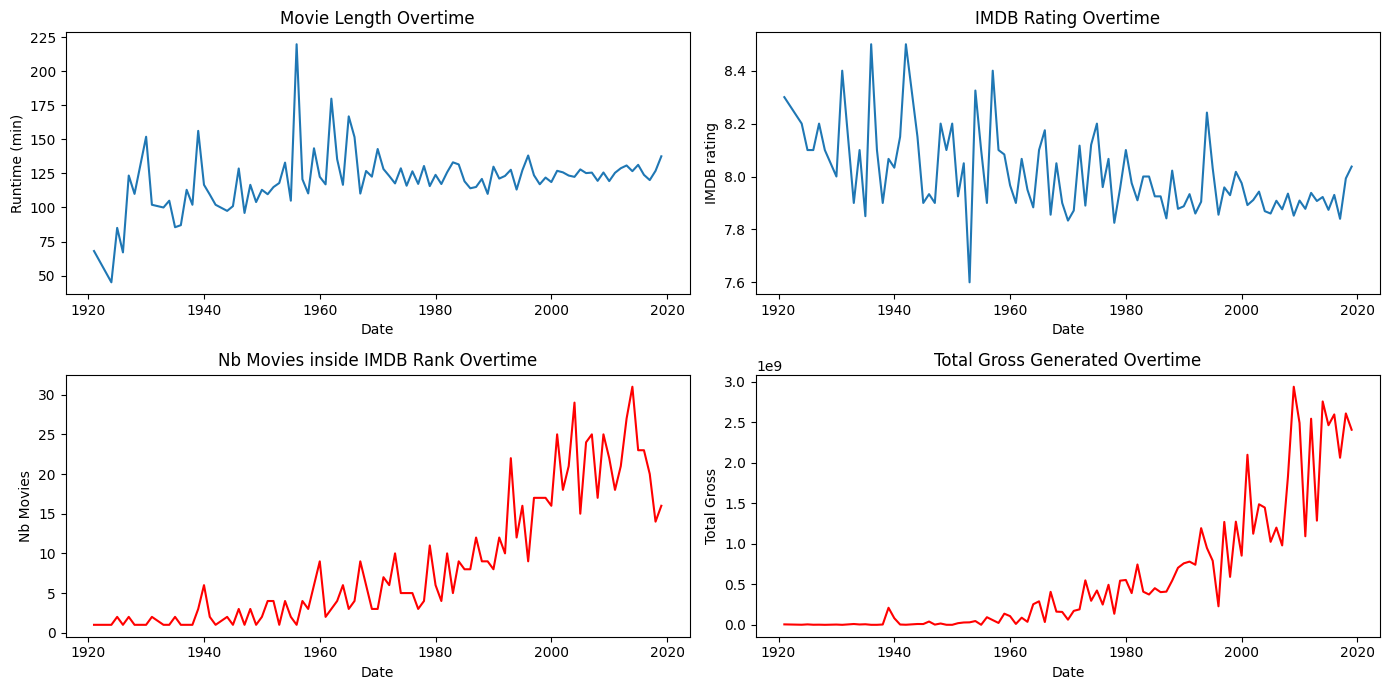

In [39]:
runtime_df = imdb_df.groupby(['released_year'])['runtime'].mean()
imdb_rating_df = imdb_df.groupby(['released_year'])['imdb_rating'].mean()
nb_movies_per_year = imdb_df.groupby(['released_year'])['series_title'].count()
total_gross_per_year = imdb_df.groupby(['released_year'])['gross'].sum()

fig, ax = plt.subplots(2, 2, figsize=(14, 7))

ax[0][0].plot(runtime_df)
ax[0][0].set_xlabel("Date")
ax[0][0].set_ylabel("Runtime (min)")
ax[0][0].set_title("Movie Length Overtime")

ax[0][1].plot(imdb_rating_df)
ax[0][1].set_xlabel("Date")
ax[0][1].set_ylabel("IMDB rating")
ax[0][1].set_title("IMDB Rating Overtime")

ax[1][0].plot(nb_movies_per_year, color='red')
ax[1][0].set_xlabel("Date")
ax[1][0].set_ylabel("Nb Movies")
ax[1][0].set_title("Nb Movies inside IMDB Rank Overtime")

ax[1][1].plot(total_gross_per_year, color='red')
ax[1][1].set_xlabel("Date")
ax[1][1].set_ylabel("Total Gross")
ax[1][1].set_title("Total Gross Generated Overtime")

plt.tight_layout()
plt.show()

We noticed for example how the number of movies integrating the IMDB rank during the 2010s decreased, but the total gross has still increased. It shows how movies generate more money overtime

#### Let's check if some Correlation Exists

Do the gross raised by the movie is correlated to the IMDB rating. Intuitively, we might think that they are positively correlated. Let's see.

In [51]:
imdb_df_adj = imdb_df[['gross', 'imdb_rating']].dropna()
corr = imdb_df_adj['gross'].corr(imdb_df_adj['imdb_rating'])

print(f"Gross and IMDB rating have a correlation of {corr:.4}. This is close to 0, which means that rating cannot be explained by gross or inversely.")

Gross and IMDB rating have a correlation of 0.09592. This is close to 0, which means that rating cannot be explained by gross or inversely.


Do the audience and critics have similar taste ?

In [52]:
imdb_df_adj = imdb_df[['imdb_rating', 'meta_score']].dropna()
corr = imdb_df_adj['meta_score'].corr(imdb_df_adj['imdb_rating'])

print(f"Meta Score and IMDB rating have a correlation of {corr:.4}. This is close to 0, but still they seem to have quite the same taste overall.")

Meta Score and IMDB rating have a correlation of 0.2827. This is close to 0, but still they seem to have quite the same taste overall.


Maybe the runtime and the gross, or the runtime and the rate then?

In [54]:
imdb_df_adj = imdb_df[['imdb_rating', 'gross', 'runtime']].dropna()
corr_1 = imdb_df_adj['gross'].corr(imdb_df_adj['runtime'])
corr_2 = imdb_df_adj['imdb_rating'].corr(imdb_df_adj['runtime'])

print(f"IMDB rating and Runtime have a correlation of {corr_2:.4}.\n")
print(f"Gross and Runtime have a correlation of {corr_1:.4}.\n")
print("The longer the movie, the better the rating it seems. While gross seems not to be related to runtime.")

IMDB rating and Runtime have a correlation of 0.2468.

Gross and Runtime have a correlation of 0.1397.

The longer the movie, the better the rating it seems. While gross seems not to be related to runtime.


#### What About the Actors?

Check who are the actors appearing the most in the IMDB rank by their role

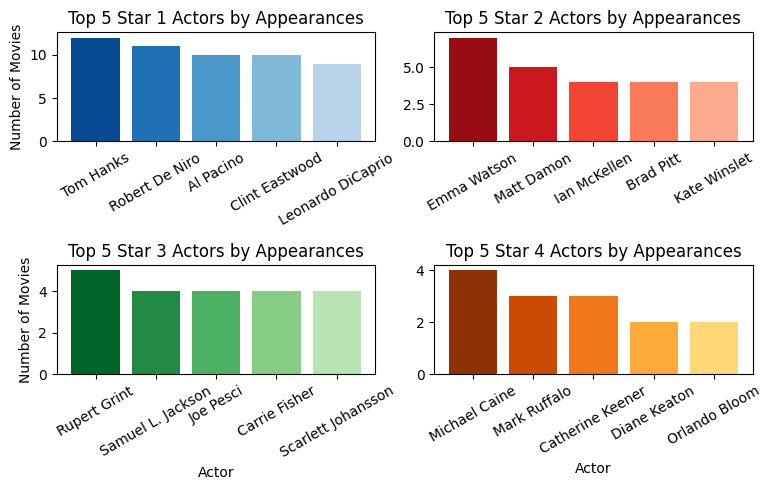

In [117]:
top_actors_1 = imdb_df['star1'].value_counts().head(5)
top_actors_2 = imdb_df['star2'].value_counts().head(5)
top_actors_3 = imdb_df['star3'].value_counts().head(5)
top_actors_4 = imdb_df['star4'].value_counts().head(5)

fig, ax = plt.subplots(2, 2, figsize=(8, 5))

ax[0][0].bar(top_actors_1.index, top_actors_1.values, color=plt.cm.Blues([0.9, 0.75, 0.6, 0.45, 0.3]))
ax[0][0].set_title("Top 5 Star 1 Actors by Appearances")
ax[0][0].set_ylabel("Number of Movies")
ax[0][0].tick_params(axis='x', rotation=30)

ax[0][1].bar(top_actors_2.index, top_actors_2.values, color=plt.cm.Reds([0.9, 0.75, 0.6, 0.45, 0.3]))
ax[0][1].set_title("Top 5 Star 2 Actors by Appearances")
ax[0][1].tick_params(axis='x', rotation=30)

ax[1][0].bar(top_actors_3.index, top_actors_3.values, color=plt.cm.Greens([0.9, 0.75, 0.6, 0.45, 0.3]))
ax[1][0].set_title("Top 5 Star 3 Actors by Appearances")
ax[1][0].set_xlabel("Actor")
ax[1][0].set_ylabel("Number of Movies")
ax[1][0].tick_params(axis='x', rotation=30)

ax[1][1].bar(top_actors_4.index, top_actors_4.values, color=plt.cm.YlOrBr([0.9, 0.75, 0.6, 0.45, 0.3]))
ax[1][1].set_title("Top 5 Star 4 Actors by Appearances")
ax[1][1].set_xlabel("Actor")
ax[1][1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Here's a cool way to see who are the top 40 star 1 actors

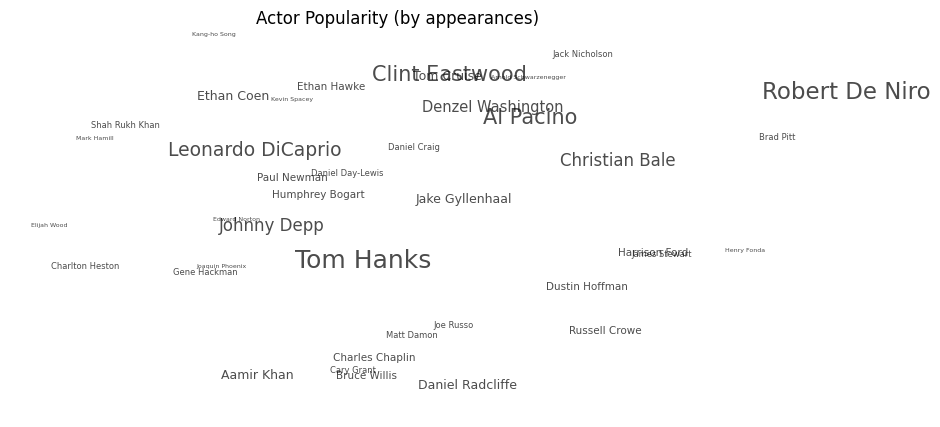

In [ ]:
actor_counts = imdb_df['star1'].value_counts().head(40)

x = np.random.rand(len(actor_counts))
y = np.random.rand(len(actor_counts))

plt.figure(figsize=(10, 5))

for i, (actor, count) in enumerate(actor_counts.items()):
    plt.text(x[i], y[i], actor, fontsize=count * 1.5, alpha=0.7)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Actor Popularity (by appearances)")
plt.axis('off')
plt.show()

#### And the Movies in all that?

Who are the real top 5 best rated movies, adjusted for the number of votes?

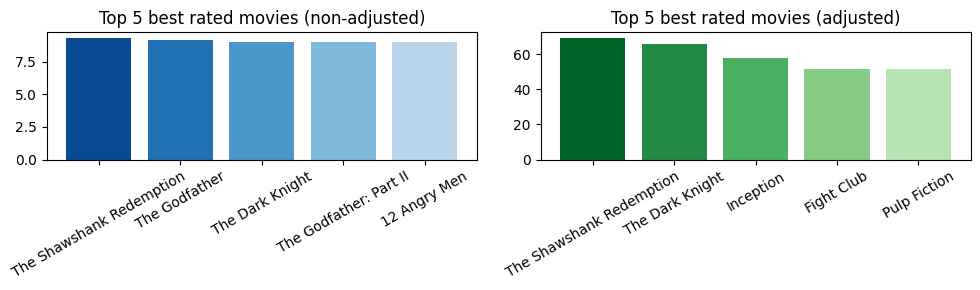

In [129]:
avg_votes = np.nanmean(imdb_df['no_of_votes'])
imdb_df['adj_imdb_rating'] = imdb_df['imdb_rating'] * imdb_df['no_of_votes'] / avg_votes

result_std = imdb_df.sort_values(by='imdb_rating', ascending=False)[['series_title', 'imdb_rating']].head(5)
result_adj_imdb_rating = imdb_df.sort_values(by='adj_imdb_rating', ascending=False)[['series_title', 'adj_imdb_rating']].head(5)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].bar(result_std['series_title'], result_std['imdb_rating'], color=plt.cm.Blues([0.9, 0.75, 0.6, 0.45, 0.3]))
ax[0].set_title('Top 5 best rated movies (non-adjusted)')
ax[0].tick_params(axis='x', rotation=30)

ax[1].bar(result_adj_imdb_rating['series_title'], result_adj_imdb_rating['adj_imdb_rating'], color=plt.cm.Greens([0.9, 0.75, 0.6, 0.45, 0.3]))
ax[1].set_title('Top 5 best rated movies (adjusted)')
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Interestingly, we noticed how Inception, Fight Club, and Pulp Fiction are even more appreciated than we might think.

#### And the Directors?

First, who are the top 5 directors in terms of appearances vs. in terms of gross raised?

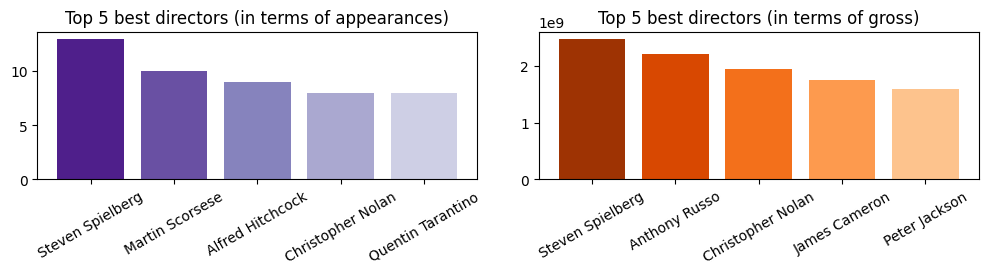

In [145]:
rank_director_1 = imdb_df['director'].value_counts().head(5)
rank_director_2 = imdb_df.groupby(['director'])['gross'].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].bar(rank_director_1.index, rank_director_1.values, color=plt.cm.Purples([0.9, 0.75, 0.6, 0.45, 0.3]))
ax[0].set_title('Top 5 best directors (in terms of appearances)')
ax[0].tick_params(axis='x', rotation=30)

ax[1].bar(rank_director_2.index, rank_director_2.values, color=plt.cm.Oranges([0.9, 0.75, 0.6, 0.45, 0.3]))
ax[1].set_title('Top 5 best directors (in terms of gross)')
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()